# **Hands-On Tutorial on Semi-Analytical Models of Cosmic Reionization**

Lecturer: Prof. Tirthankar Roy Choudhury

School : Physics of Galaxy Formation, IUCAA Pune

Date : June 15, 2026

Tutor : Anirban Chakraborty (Email : anirban.chakraborty096@gmail.com)

# **Preliminary : Start a new Google Colab session**

If you have already executed this notebook once and the software installation or working folders are still present on the virtual machine, you must first clear them. To do this, follow these steps:


1.   Go to  ```Runtime``` in the top menu and select the ```Disconnect and delete runtime``` option.

2.   If the session does not reconnect automatically, click the ```Reconnect``` button in the top-right corner of the Google Colab screen interface.







## **Part 0 : Install the required software packages and libraries**

We will use the publically available [Colossus](https://bdiemer.bitbucket.io/colossus/index.html) package to perform various cosmological calculations relevant to this tutorial, such as computing cosmological quantities, halo mass functions etc

In [2]:
import numpy as np
import pylab as plt
import colossus
# NumPy: library for numerical computations and array operations
import numpy as np

# Matplotlib: library for generating and displaying plots
import matplotlib.pyplot as plt
import matplotlib


plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['xtick.labelsize']=18
plt.rcParams['ytick.labelsize']=18
plt.rcParams.update({'font.size': 22})
plt.rcParams.update({'font.family':'serif'})

## Create a working directory

In [4]:
# import os

# # Define the base directory
# # The default temporary working directory on the remote Linux virtual machine provided by Google Colab is '/content'

base_path = ""

# # Create the path for a new working directory called "work"
# work_path = os.path.join(base_path, "work")

# # Create the directory if it does not already exist
# os.makedirs(work_path, exist_ok=True)

# # Change the current working directory to the newly created "work" folder
# os.chdir(work_path)

# # Print and confirm the current working directory
# os.getcwd()


Create a folder in the working directory to store all saved plots from the session

In [ ]:
# # Create a directory named "figures" in the  working directory
# # for storing figures from this tutorial

# os.makedirs("figures", exist_ok=True)

Let us now import the required python libraries

In [ ]:
# Modules used for interacting with the operating system and Python environment

# import os, sys

# Add the current working directory to Python's module search path
# sys.path.append(os.getcwd())



# Defining the Cosmological Model


In [3]:
from colossus.cosmology import cosmology

# Define the cosmological parameters (Planck 2015 values)

omega_m = 0.308                     # Total matter density parameter
omega_b = 0.0482                    # Baryon density parameter
h = 0.678                           # Dimensionless Hubble parameter (H0 = 100 h km s^-1 Mpc^-1)
sigma_8 = 0.829                     # RMS matter fluctuation amplitude on scales of 8 Mpc/h
n_s = 0.961                         # Primordial scalar spectral index
Yp = 0.24                           # Primordial helium mass fraction


# Initialize and register the cosmology in Colossus
my_cosmo_params = {'flat': True, 'H0': 100*h, 'Om0': omega_m, 'Ob0': omega_b, 'sigma8': sigma_8, 'ns': n_s}

cosmo = cosmology.setCosmology('my_cosmo', **my_cosmo_params,  persistence = '')

# Display a summary of the cosmological model
print(cosmo)

Cosmology "my_cosmo" 
    flat = True, Om0 = 0.3080, Ode0 = 0.6919, Ob0 = 0.0482, H0 = 67.80, sigma8 = 0.8290, ns = 0.9610
    de_model = lambda, relspecies = True, Tcmb0 = 2.7255, Neff = 3.0460, powerlaw = False


# **Background: The Global Reionization Equation**

The evolution of the globally averaged ionized hydrogen fraction, $Q_{\mathrm{HII}}(z)$, is described by the balance between the production of ionizing photons and recombinations in the intergalactic medium (IGM),

\begin{equation}
    \frac{\mathrm{d}Q_{\mathrm{HII}}}{\mathrm{d}t}
    =
    \frac{\dot{n}_{\mathrm{ion}}}{\bar{n}_{\mathrm{H}}}
    -
    \frac{Q_{\mathrm{HII}}}{t_{\mathrm{rec}}},
    \tag{1}
\end{equation}

where $\dot{n}_{\mathrm{ion}}$ is the comoving ionizing photon emissivity and $\bar{n}_{\mathrm{H}}$ is the mean comoving hydrogen number density.

The recombination timescale is given by

\begin{equation}
    t_{\mathrm{rec}}^{-1}
    =
    C_{\mathrm{HII}}\,
    \alpha_{\mathrm{B}}(T)\,
    \chi_{\mathrm{He}}(z)\,
    \bar{n}_{\mathrm{H}}
    (1+z)^3,
    \tag{2}
\end{equation}

where $C_{\mathrm{HII}}$ is the clumping factor of ionized gas, $\alpha_{\mathrm{B}}(T)$ is the case-B recombination coefficient, and

\begin{equation}
    \chi_{\mathrm{He}}(z)
    =
    1+\eta\,\frac{Y_p}{4X_p},
    \tag{3}
\end{equation}

is the number of free electrons per hydrogen atom, including the contribution from helium. Here $X_p$ and $Y_p$ denote the primordial hydrogen and helium mass fractions, respectively, and $\eta$ specifies the ionization state of helium ($\eta=1$ for singly ionized helium and $\eta=2$ for doubly ionized helium).

Assuming that helium is singly ionized for $z \geq 3$ and doubly ionized for $z < 3$, with $X_p=0.76$ and $Y_p=0.24$, we obtain

\begin{equation}
\chi_{\mathrm{He}}(z) =
\begin{cases}
1.08, & z \geq 3,\\
1.16, & z < 3.
\end{cases}
\tag{4}
\end{equation}


Therefore, to solve the global reionization history, we need two key astrophysical inputs :



1. **Ionizing photon emissivity**, $\dot{n}_{\mathrm{ion}}(z)$, which sets the rate at which ionizing photons are supplied to the intergalactic medium.

2. **Ionized-gas clumping factor**, $C_{\mathrm{HII}}$, which regulates the recombination rate within ionized regions.

In [ ]:
########################################################
################    Useful constants     ###############
########################################################


km_to_cm = 1e5                              # Conversion factor from km to cm
cm_to_km = 1/km_to_cm                       # Conversion factor from cm to km


Mpc_to_cm = 3.08567758149e+24               # Conversion factor from Mpc to cm
cm_to_Mpc = 1/Mpc_to_cm                     # Conversion factor from cm to Mpc


yr_to_sec = 31556925.27                     # Conversion factor from years to seconds
sec_to_yr = 1/yr_to_sec                     # Conversion factor from seconds to years

Msun_to_gram = 1.9884754153381438e+33       # Conversion factor from Msun to grams
gram_to_Msun = 1/Msun_to_gram               # Conversion factor from grams to Msun



m_proton = 1.672621898e-24                  # Mass of a proton in gram
sigma_T = 6.6524587158e-25                  # Thomson scattering cross-section (cm^2)
c = 2.99792458e10                           # Speed of light in vacuum (cm s^-1)


########################################################
################ Cosmological quantities ###############
########################################################
from colossus import utils
rho_crit = utils.constants.RHO_CRIT_0_MPC3  # The critical density of the universe at z = 0 in units of Msun h^2 / Mpc^3

rho_crit = rho_crit * cosmo.h**2            # Convert rho_crit to units of Msun / Mpc^3

rho_m = cosmo.Om0 * rho_crit                # Mean comoving matter density of the universe in units of Msun / Mpc^3
rho_b = cosmo.Ob0 * rho_crit                # Mean comoving baryon density of the universe in units of Msun / Mpc^3

rho_H = (1-Yp) * rho_b                      # Mean comoving hydrogen mass density in units of Msun / Mpc^3
rho_H = rho_H * Msun_to_gram                # rho_H in units of grams / Mpc^3

nH = rho_H / m_proton                       # Mean comoving number density of hydrogen atoms in units of Mpc^-3

# Defining the Ionizing Photon Emissivity Model ($\dot{n}_{\mathrm{ion}}$)

We define the ionizing photon production rate per unit comoving volume as follows

$$
    \dot n_{\rm ion}(t)
    =
    \bar n_{\rm H} \, \frac{\mathrm{d}}{\mathrm{d}t}
    \langle
    \zeta f_{\rm coll}(M_{\rm min},t)
    \rangle  \, ,
    \tag{5}
$$

where

$$
    \left\langle
    \zeta f_{\rm coll}(M_{\rm min},t)
    \right\rangle
    \equiv
    \frac{1}{\bar{\rho}_m}
    \int_{M_{\rm min}}^\infty
    dM\,
    \zeta(M,t)\,
    M\,
    \frac{\mathrm{d}n(M,t)}{\mathrm{d}M}.
    \tag{6}
$$

Here, $\zeta(M,t) = f_* f_{esc}\eta_\gamma$ is the ionizing efficiency of halos of mass $M$, $dn/dM$ is the halo mass function, and $\bar{\rho}_m$ is the mean comoving matter density.

For a mass- and redshift-independent ionizing efficiency, $\zeta(M,t)=\zeta$, the above expression reduces to

$$
    \dot n_{\rm ion}(t)
    =\bar n_{\rm H} \,
    \zeta
    \frac{\mathrm{d} f_{\rm coll}(M_{\rm min},t)}{\mathrm{d}t},
    \tag{7}
$$

where

$$
    f_{\rm coll}(M_{\rm min},t)
    =
    \frac{1}{\bar{\rho}_m}
    \int_{M_{\rm min}}^\infty
    dM\,
    M\,
    \frac{\mathrm{d}n(M,t)}{\mathrm{d}M}.
    \tag{8}
$$

This quantity constitutes the source term in the global reionization equation.

 In the most general case, the quantity $\langle \zeta f_{\rm coll}\rangle$ must therefore be obtained by appropriately integrating the halo mass function.

In the Press-Schechter formalism, the halo mass function is given by the following expression :

\begin{equation}
    \left[ \frac{dn}{dM} \right]_{\rm PS}
    =
    \sqrt{\frac{2}{\pi}} \,
    \frac{\bar{\rho}_m}{M^2} \,
    \nu(M,z) \,
    \left|
    \frac{d\ln\sigma}{d\ln M}
    \right| \,
    \exp\!\left[-\frac{\nu^2(M,z)}{2}\right],
    \tag{9}
\end{equation}

where

\begin{equation}
    \nu(M,z)
    \equiv
    \frac{\delta_c}{\sigma(M,z)}
\end{equation}

is the peak height, $\delta_c=1.68647$ is the critical overdensity for spherical collapse, and $\sigma(M,z)=D(z)\sigma(M,0)$ is the rms fluctuation of the linear density field on mass scale $M$ at redshift $z$.

In this notation, the collapsed fraction above a minimum halo mass $M_{\rm min}$ has the following clean analytic form :

\begin{equation}
    f^{\rm PS}_{\rm coll}(M_{\rm min},z)
    =
    \mathrm{erfc}
    \left[
    \frac{\nu_{\rm min}(z)}
    {\sqrt{2}}
    \right],
    \tag{10}
\end{equation}

where

\begin{equation}
    \nu_{\rm min}(z)
    =
    \frac{\delta_c}
    {\sigma(M_{\rm min},z)}
\end{equation}

is the peak height corresponding to the minimum halo mass at redshift $z$.

## **Exercise 1: Collapsed Fraction in Press–Schechter Theory**

### a. Analytic Derivation
Starting from the expression for the Press–Schechter halo mass function,
given in Eq. (9), derive the analytic expression for the collapsed fraction,
$
f_{\rm coll}^{\rm PS},
$
quoted in Eq. (10).

### b. Numerical Verification
Evaluate $f_{\rm coll}^{\rm PS}$ by integrating the Press–Schechter mass function appropiately (see Eq.(8)) and verify that the numerical result agrees with the analytic expression given in Eq. (10).

In [7]:
from scipy.integrate import simpson
from scipy.special import erfc
from colossus.cosmology import cosmology
from colossus.lss import mass_function
from colossus.lss import peaks

def fcoll_PS(Mmin, z):
    """
    Compute the Press–Schechter collapsed fraction above a minimum
    halo mass Mmin at redshift z.

    Parameters
    ----------
    Mmin : float
        Minimum halo mass threshold in Msun/h.
    z : float
        Redshift.

    Returns
    -------
    fcoll_value : float
        Fraction of matter collapsed into halos with M > Mmin.
    """

    # Peak height corresponding to the mass threshold Mmin
    nu_Mmin_z = peaks.peakHeight(Mmin, z)

    # Analytic Press–Schechter expression:
    # f_coll(Mmin,z) = erfc[nu(Mmin,z)/sqrt(2)]
    fcoll_value = erfc(nu_Mmin_z / np.sqrt(2.0))

    return fcoll_value

def H_of_z(z):
    """
    Compute the Hubble parameter at redshift z.

    Parameters
    ----------
    z : float
        Redshift.

    Returns
    -------
    H_z : float
        Hubble parameter in 1/secs.
    """

    # cosmo.H(z) has units of km/s/Mpc
    H_z = cosmo.Hz(z) * km_to_cm / Mpc_to_cm

    return H_z

\begin{align}
    f_{coll} = \frac{1}{\bar{\rho_m}}\int dM M \frac{dn}{dM}\\
    f_{coll} = \frac{1}{\bar{\rho_m}}\int d\ln M M \frac{dn}{d\ln M}\\
    M = \frac{d\ln M}{d M}
\end{align}

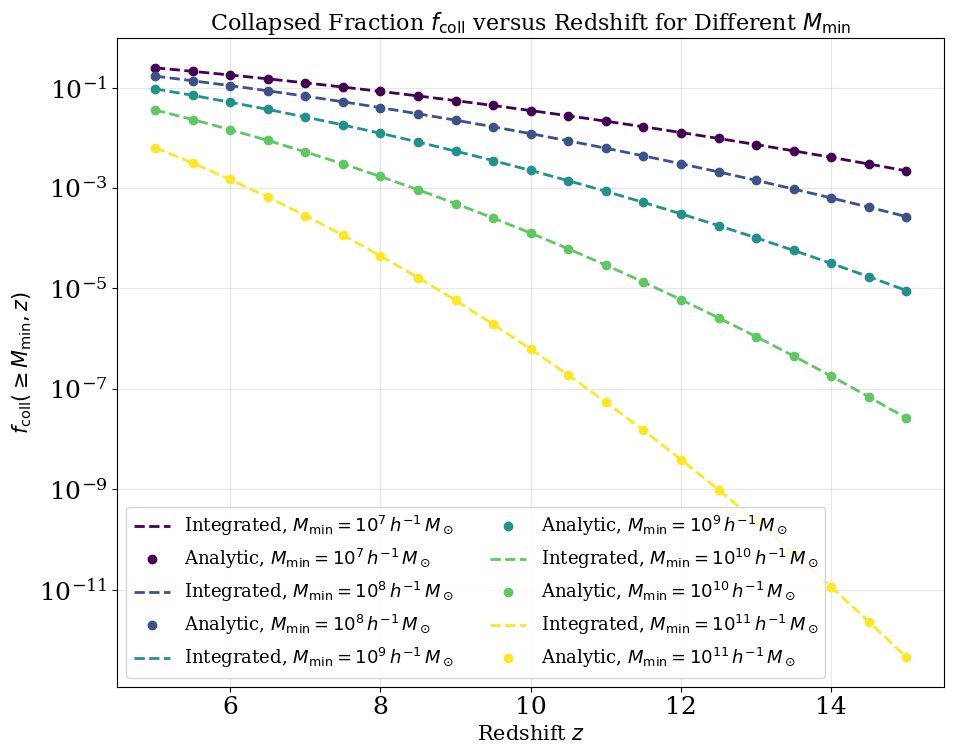

In [8]:
# ---------------------------------------------------------
# Compare the analytic and numerically integrated estimates
# of the Press–Schechter collapsed fraction, f_coll
# ---------------------------------------------------------

# Create the figure and axes
fig, ax = plt.subplots(figsize=(10, 8))

# Minimum halo mass thresholds (Msun/h)
Mmin_list = [1e7, 1e8, 1e9, 1e10, 1e11]

# Redshift range over which f_coll will be evaluated
z_arr = np.linspace(5, 15, 21)


# Halo mass array (Msun/h) used for numerical integration
M = np.logspace(6, 15, 1000)


# Choose a distinct colour for each minimum halo mass threshold
colors = plt.cm.viridis(np.linspace(0, 1, len(Mmin_list)))


# Loop over the different minimum halo mass thresholds
for Mmin, color in zip(Mmin_list, colors):

    # Lists to store the numerical and analytic estimates
    fcoll_integrated = []
    fcoll_analytic = []

    # Compute f_coll at each redshift
    for z in z_arr:

        # =====================================================
        # Method 1: Numerical integration (Eq. 8)
        # =====================================================

        # Press–Schechter halo mass function:
        # dndlnM = dn/dlnM (h^3 Mpc^-3)
        dndlnM = mass_function.massFunction(M, z,
            mdef='fof',
            model='press74',
            q_out='dndlnM'
        )

        # Select halos with masses above the threshold Mmin
        mask = M >= Mmin

        # Integrand:
        # M (dn/dlnM)
        # units : Msun/h * h^3 Mpc^-3 = h^2 Msun Mpc^-3
        integrand_fcoll = M[mask] * dndlnM[mask]

        # convert integrand_fcoll to units of Msun Mpc^-3
        integrand_fcoll = integrand_fcoll * cosmo.h**2

        # Evaluate f_coll using Simpson's rule

        fcoll_numeric = (1 / rho_m) * simpson(integrand_fcoll,x=np.log(M[mask]))

        # Store the numerical result
        fcoll_integrated.append(fcoll_numeric)

        # =====================================================
        # Method 2: Analytic expression (Eq.8)
        # =====================================================

        # Evaluate
        # f_coll = erfc[nu(Mmin,z)/sqrt(2)]

        fcoll_exprn = fcoll_PS(Mmin, z)

        # Store the analytic result
        fcoll_analytic.append(fcoll_exprn)





    # Plot the numerically integrated collapsed fraction
    ax.semilogy(
        z_arr,
        fcoll_integrated,
        '--',
        color=color,
        lw=2,
        label=rf'Integrated, $M_{{\min}}=10^{{{int(np.log10(Mmin))}}}\,h^{{-1}}\,M_\odot$'
    )

    # Plot the analytic Press–Schechter prediction
    ax.semilogy(
        z_arr,
        fcoll_analytic,
        marker='o',
        ls='',
        color=color,
        ms=6,
        label=rf'Analytic, $M_{{\min}}=10^{{{int(np.log10(Mmin))}}}\,h^{{-1}}\,M_\odot$'
    )


ax.set_xlabel(r'Redshift $z$', fontsize=15)
ax.set_ylabel(r'$f_{\rm coll}(\geq M_{\rm min},z)$', fontsize=15)
ax.set_title(
    r'Collapsed Fraction $f_{\rm coll}$ versus Redshift for Different $M_{\rm min}$',
    fontsize=16
)
ax.grid(alpha=0.3)
ax.legend(fontsize=13, ncol=2)

plt.tight_layout()
plt.savefig('figures/fcoll_z_all_Mmin.png', dpi=300)
plt.show()

## **Exercise 1** :

### a. Write a function `niondot(z, zeta, Mmin)` that takes as input the redshift `z`, ionizing efficiency `zeta`, and minimum halo mass `Mmin`, and computes the ionizing photon emissivity. This function should return $\dot{n}_{\rm ion}$ in units of $\rm s^{-1}\,cMpc^{-3}$.

$$
    \dot{n}_{\rm ion}
    =
    \zeta \, \bar{n}_{\rm H}
    \frac{\mathrm{d} f_{\rm coll}}{\mathrm{d}t}.
$$


### b. For $\zeta$ = 25 and $M_\mathrm{min} = 10^8 h^{-1} M_\odot$, plot the redshift evolution of $\dot{n}_{\rm ion}$ across the range  $z=5$ to $z=20$





[Cheatsheet](https://docs.google.com/document/d/1K5cbzBErBVgJ8ZC7EKcRa0o8TxBkdOnFqFLjqItAYeg/edit?usp=sharing)

In [ ]:
def niondot(z, zeta, Mmin):
    """
    Compute the comoving ionizing photon emissivity.

          niondot = nH * zeta * (df_coll/dt),
                  = nH * zeta * (df_coll/dz) / (dt/dz),

    Parameters
    ----------
    z : float
        Redshift at which the emissivity is evaluated.
    zeta : float
        Ionizing efficiency parameter.
    Mmin : float
        Minimum halo mass threshold (Msun/h) used in the collapsed
        fraction calculation.

    Returns
    -------
    niondot : float
        Comoving ionizing photon emissivity (photons s^-1 Mpc^-3).
    """

    # Hubble parameter at redshift z (s^-1)
    H_z = H_of_z(z)

    ######################################
    ####### Your code goes here ##########
    ######################################
    deltaz = 0.1
    dt_by_dz = -1/(H_z*(1+z))

    # differentiate using central difference method
    dfcoll_by_dz = (fcoll_PS(Mmin, z+deltaz)-fcoll_PS(Mmin, z-deltaz))/(2*deltaz) 
    dfcoll_by_dt = dfcoll_by_dz/dt_by_dz # by chain rule

    # Comoving ionizing photon emissivity (photons s^-1 Mpc^-3)
    niondot = nH * zeta * dfcoll_by_dt

    return niondot

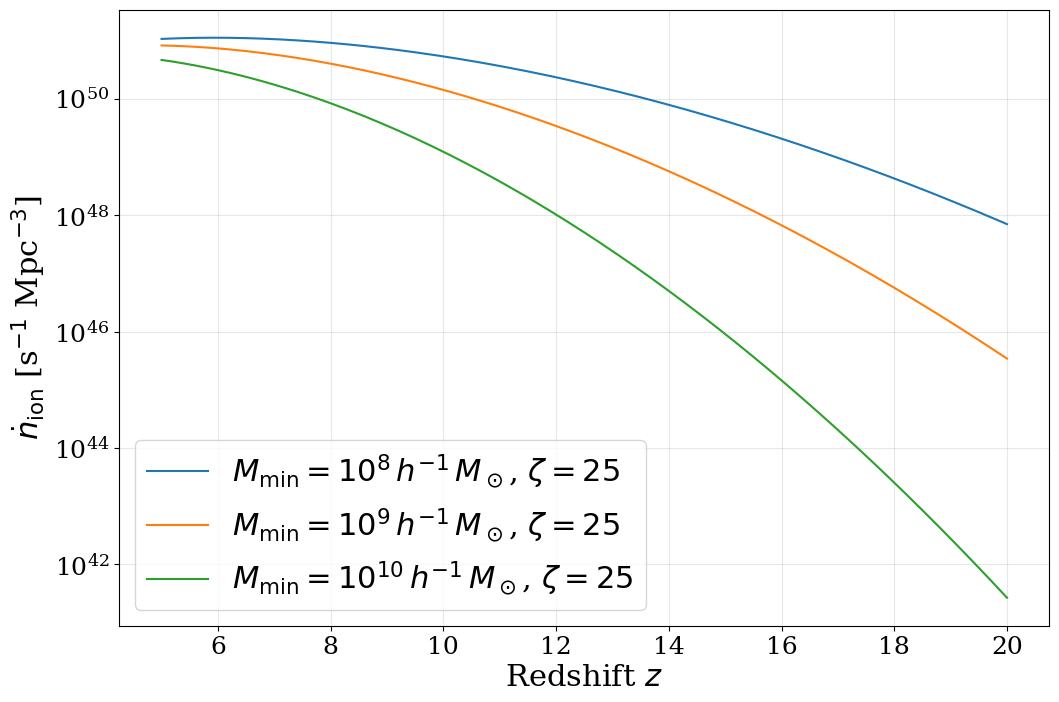

In [32]:
##################################################################
# Plot the comoving ionizing photon emissivity as a function of
# redshift for a fixed ionizing efficiency and minimum halo mass
##################################################################

# Redshift range over which the emissivity will be evaluated
zlist = np.linspace(5, 20, 151)

for Mmin in [1e8,1e9,1e10]: 
    # Model parameters
    # Mmin = 1e8   # Minimum halo mass threshold (Msun/h)
    zeta = 25    # Ionizing efficiency parameter

    # Compute the ionizing emissivity at each redshift
    niondot_arr = []
    for z in zlist:
        niondot_arr.append(niondot(z, zeta, Mmin))

    # Plot the evolution of the ionizing emissivity
    plt.plot(
        zlist,
        niondot_arr,
        label=rf'$M_{{\min}}=10^{{{int(np.log10(Mmin))}}}\,h^{{-1}}\,M_\odot$, '
            rf'$\zeta={zeta}$'
    )

# Label the axes
plt.xlabel('Redshift $z$')
plt.ylabel(r'$\dot{n}_{\rm ion}$ [s$^{-1}$ Mpc$^{-3}$]')

# Use a logarithmic scale because the emissivity spans several orders of magnitude
plt.yscale('log')
plt.grid(alpha=0.3)
plt.legend()
plt.savefig(f'figures/niondot_zeta_{zeta}_log10Mmin_{np.log10(Mmin)}.png', dpi=300)
plt.show()

# Exercise 2: Solving the Global Reionization Equation

#### a. Using the `niondot(z, zeta, Mmin)` function developed in Exercise 1,  write a function that accepts the clumping factor `C`, ionizing efficiency `zeta`, and minimum halo mass `Mmin`, and solves the global reionization equation,

$$
    \frac{dQ_{\rm HII}}{dt}
    =
    \frac{\dot{n}_{\rm ion}}{\bar{n}_{\rm H}}
    -
    \frac{Q_{\rm HII}}{t_{\rm rec}},
$$

$$
    \frac{dQ_{\rm HII}}{dz}
    =
    \frac{dt}{dz}
    \left[
    \frac{\dot{n}_{\rm ion}}{\bar{n}_{\rm H}}
    -
    \frac{Q_{\rm HII}}{t_{\rm rec}}
    \right],
$$

where

$$
    \frac{dt}{dz}
    =
    -\frac{1}{(1+z)H(z)}.
$$


and

$$
    t_{\mathrm{rec}}^{-1}
    =
    C_{\mathrm{HII}}\,
    \alpha_{\mathrm{B}}\,
    \chi_{\mathrm{He}}(z)\,
    \bar{n}_{\mathrm{H}}
    (1+z)^3,
$$


Using the forward Euler method, the reionization equation can be integrated as

$$
    Q_{{\rm HII},\,i+1}
    =
    Q_{{\rm HII},\,i}
    +
    \left(\frac{dQ_{\rm HII}}{dz}\right)_i
    \Delta z,
$$

#### b. For $C_\mathrm{HII} = 3$, $\zeta$ = 25 and $M_\mathrm{min} = 10^8 h^{-1} M_\odot$, plot the evolution of $Q_{\rm HII}(z)$ over the redshift range  $z=5$ to $z=15$

(Homogenous universe $\implies C_\mathrm{HII} = 1$ )





[Cheatsheet](https://docs.google.com/document/d/1K5cbzBErBVgJ8ZC7EKcRa0o8TxBkdOnFqFLjqItAYeg/edit?usp=sharing)

In [ ]:
def get_QHII_arr(C_HII, zeta, Mmin):
    """
    Solve the reionization equation and compute the evolution of the
    globally-averaged ionized fraction, Q_HII(z).

    Parameters
    ----------
    C_HII : float
        Clumping factor of ionized hydrogen.
    zeta : float
        Ionizing efficiency parameter.
    Mmin : float
        Minimum halo mass threshold (Msun/h) used in the collapsed
        fraction calculation.

    Returns
    -------
    z_arr : ndarray
        Redshift array from z = 20 to z = 0.
    QHII_arr : ndarray
        Globally-averaged ionized fraction corresponding to each redshift.
    z_end : float or None
        Redshift at which reionization completes, defined as the first
        redshift for which Q_HII = 1. Returns None if the ionized fraction
        does not reach unity within the integration range.
    """

    # Redshift grid over which the reionization equation is integrated
    z_arr = np.linspace(20.0, 0.0, 201)

    # Case-B recombination coefficient at T = 10^4 K (cm^3 s^-1)
    alpha_B = 2.6e-13
    alpha_B *= cm_to_Mpc**3 # since nH is in Mpc^3

    # Array to store the ionized fraction history
    QHII_arr = np.zeros_like(z_arr)

    # Helium correction factor accounting for extra free electrons
    # from singly (z >= 3) and doubly (z < 3) ionized helium
    chiHe_arr = np.where(z_arr >= 3.0, 1.08, 1.16)

    # Initial condition: assume the Universe is completely neutral at z = 20
    QHII_arr[0] = 0.0

    # Integrate the reionization equation using Euler's method
    for i in range(len(z_arr) - 1):

        # Current redshift and ionized fraction
        z = z_arr[i]
        QHII = QHII_arr[i]
        chiHe = chiHe_arr[i]

        ######################################
        ####### Your code goes here ##########
        ######################################

        dt_dz = -1/(H_of_z(z)*(1+z))

        # Hydrogen recombination time (units = secs)
        t_rec = 1/(C_HII*alpha_B*chiHe*nH*(1+z)**3)

        # Source term: number of ionizations per hydrogen atom per second
        # nH_percm3 = nH/(Mpc_to_cm**3) # don't need since we converted alpha
        source_term = niondot(z, zeta, Mmin)/nH

        # Sink term: loss of ionized hydrogen due to recombinations
        recomb_term = QHII/t_rec

        # Time derivative of the ionized fraction
        dQHII_dt = source_term - recomb_term

        # Convert the derivative from dQ/dt to dQ/dz
        dQHII_dz = dQHII_dt*dt_dz

        # Redshift step
        dz = z_arr[i + 1] - z_arr[i]

        # Euler update
        QHII_arr[i + 1] = QHII + dQHII_dz*dz

        # Enforce the physical condition: Q_HII cannot exceed unity
        if QHII_arr[i + 1] >= 1.0:
            QHII_arr[i + 1] = 1.0

    # Redshift at which reionization ends, defined as the first redshift
    # at which the Q_HII reaches unity

    if np.any(QHII_arr == 1.0): # why?
        z_end = z_arr[np.argmax(QHII_arr == 1.0)]
    else:
        z_end = None  # Reionization not completed within the integration range

    return z_arr, QHII_arr, z_end

Reionization completes at z = 6.90


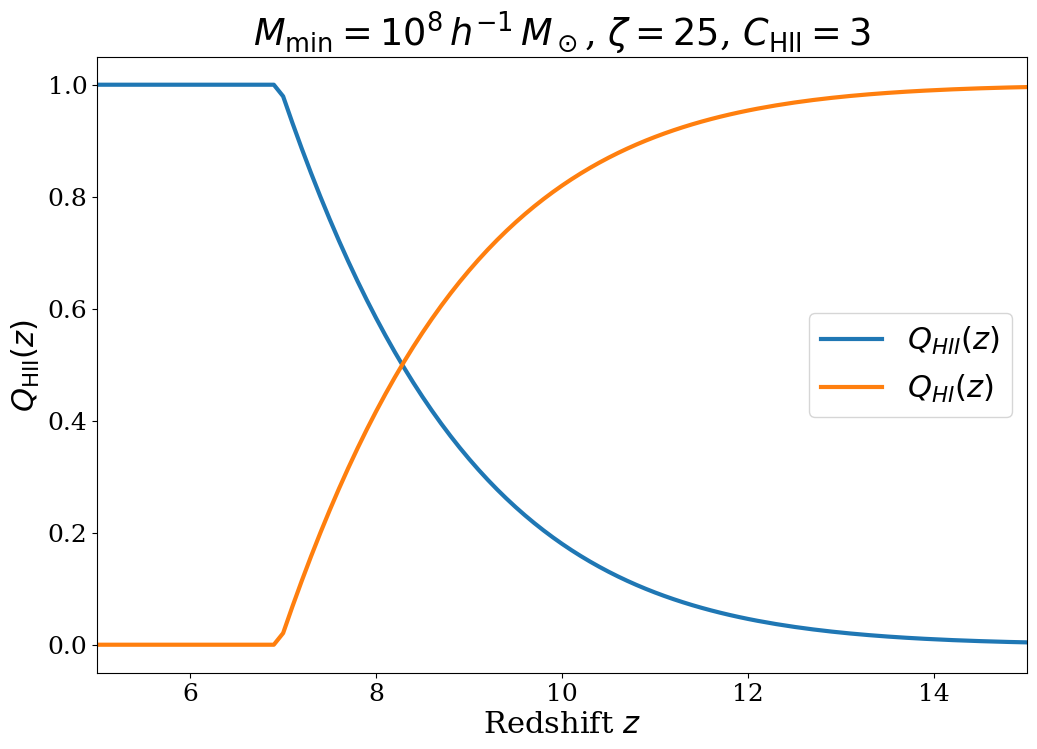

In [25]:
##################################################################
# Compute the global ionization history for a given set of
# reionization parameters
##################################################################

C_HII = 3      # Clumping factor of ionized hydrogen
zeta = 25      # Ionizing efficiency parameter
Mmin = 1e8     # Minimum halo mass threshold (Msun/h)

# Solve the reionization equation
z_arr, Qion_arr, z_end = get_QHII_arr(C_HII, zeta, Mmin)

# Print the redshift at which reionization completes
if z_end is not None:
    print(f"Reionization completes at z = {z_end:.2f}")
else:
    print("Reionization is not completed within the redshift range considered.")

# Plot the evolution of the volume-averaged ionized fraction
plt.plot(z_arr, Qion_arr, lw=3,
    label='$Q_{HII}(z)$'
)
plt.plot(z_arr, 1-Qion_arr, lw=3,
    label='$Q_{HI}(z)$'
)
plt.title(rf'$M_{{\min}}=10^{{{int(np.log10(Mmin))}}}\,h^{{-1}}\,M_\odot$, '
          rf'$\zeta={zeta}$, $C_{{\rm HII}}={C_HII}$')

# Label the axes
plt.xlabel('Redshift $z$')
plt.ylabel(r'$Q_{\rm HII}(z)$')

plt.xlim(5, 15)
plt.legend()
plt.savefig(f'figures/reion_hist_zeta_{zeta}_log10Mmin_{np.log10(Mmin)}_clumping_{C_HII}.png', dpi=300)
plt.show()

# Exercise 3: Calculating the Reionization Optical Depth from $Q_{\rm HII}(z)$

Having obtained the reionization history $Q_{\rm HII}(z)$, we can also calculate the Thomson scattering optical depth for CMB photons (due to free electrons produced by cosmic reionization) as follows,

\begin{align}
    \tau_{\mathrm e}(z)
    &=
    \sigma_T\,c\,\bar n_H
    \int_0^z dz'\,
    \left|\frac{dt'}{dz'}\right|
    \chi_{\rm He}(z')
    Q_{\rm HII}(z')
    (1+z')^3 \\
    &=
    \sigma_T\,c\,\bar n_H
    \int_0^z
    \frac{dz'}{H(z')}
    (1+z')^2
    \chi_{\rm He}(z')
    Q_{\rm HII}(z').
\end{align}

The total optical depth due to reionization is then obtained by evaluating the above expression at the redshift of the last-scattering surface, $z_{\rm LSS}\simeq1100$, (but $Q_\mathrm{HII}$ goes to zero way before 1100, so we don't need to compute it)

\begin{equation}
    \tau_{\rm reion}
    =
    \tau_{\mathrm e}(z_{\rm LSS}).
\end{equation}

#### a.  Write a function `get_reion_tau(z_arr, QHII_arr)` that accepts `z_arr` and `QHII_arr` as input and computes the electron-scattering optical depth, $\tau_{\rm e}(z)$

#### b. Plot the cumulative electron-scattering optical depth history, $\tau_{\rm e}(z)$, as a function of redshift.

In [26]:
from scipy.integrate import cumulative_trapezoid

def get_reion_tau(z_arr, QHII_arr):
    """
    Compute the Thomson scattering optical depth due to reionization.

    Parameters
    ----------
    z_arr : ndarray
        Redshift array.
    QHII_arr : ndarray
        Globally-averaged ionized fraction corresponding to each redshift.

    Returns
    -------
    tau_arr : ndarray
        Thomson scattering optical depth integrated from each redshift
        to the present day (z = 0).
    tau_reion : float
        Total optical depth due to reionization.

    Notes
    -----
    If the input redshift array is in decreasing order (e.g., from
    z = 20 to z = 0), the redshift and QHII arrays are first
    reversed so that the integration is performed over an increasing
    redshift grid, as required by `cumulative_trapezoid`.
    """

    flag_input_zarr_descending = (z_arr[0] > z_arr[-1])


    # Reverse arrays if z_arr is in decreasing order
    if flag_input_zarr_descending:
        print("[get_reion_tau] Reversing inputs so that z is in increasing order")
        z_arr = z_arr[::-1]
        QHII_arr = QHII_arr[::-1]


    # ------------------------------------------------------------
    # Compute tau_el on the increasing redshift grid
    # ------------------------------------------------------------


    # Helium correction factor accounting for additional free electrons
    # from singly (z >= 3) and doubly (z < 3) ionized helium
    chiHe_arr = np.where(z_arr >= 3.0, 1.08, 1.16)

    # Hubble parameter evaluated at each redshift (s^-1)
    Hz_arr = np.array([H_of_z(z) for z in z_arr])

    # Integrand of the optical depth integral:
    # chiHe(z) * Q_HII(z) * (1+z)^2 / H(z)
    # units : s

    ######################################
    ####### Your code goes here ##########
    ######################################

    integrand_tau = chiHe_arr*QHII_arr*(1+z_arr)**2 / Hz_arr

    # Number density of hydrogen atoms in cm^-3
    nH_per_cmcubed = nH / (Mpc_to_cm**3)

    # Prefactor term of the optical depth integral:
    # sigma_T * c * n_H
    # units = cm^2 * cm/s * cm^-3 = s^-1

    ######################################
    ####### Your code goes here ##########
    ######################################

    prefactor_tau = sigma_T*c*nH_per_cmcubed

    # Cumulative Thomson optical depth
    tau_arr = prefactor_tau * cumulative_trapezoid(
                            integrand_tau,
                            z_arr,
                            initial=0.0)

    tau_reion = tau_arr[-1]

    # Restore the original ordering of the output array if input arrays were reversed
    if flag_input_zarr_descending:
        tau_arr = tau_arr[::-1]

    return tau_arr, tau_reion

[get_reion_tau] Reversing inputs so that z is in increasing order
tau_reion = 0.0652


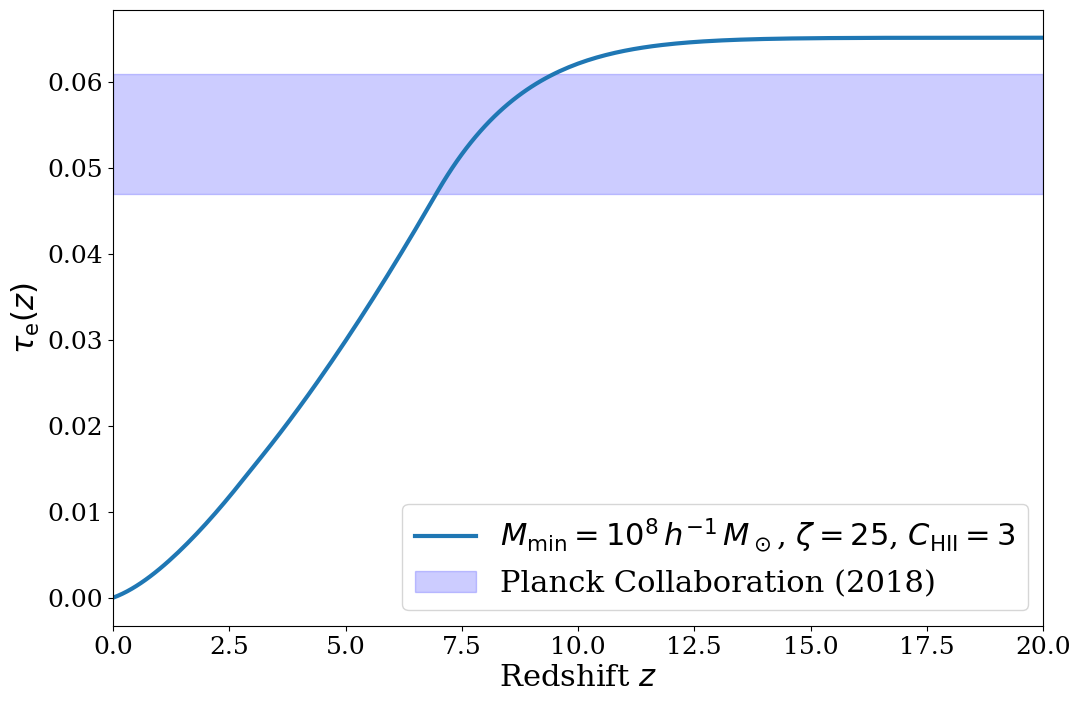

In [27]:
#####################################################################
# Compute the global ionization history and the electron scattering
# optical depth for the fiducial reionization model
#####################################################################

# Reionization model parameters
C_HII = 3       # Clumping factor of ionized hydrogen
zeta = 25       # Ionizing efficiency parameter
Mmin = 1e8      # Minimum halo mass threshold (Msun/h)

# Solve for the ionization history
z_arr, QHII_arr, z_end = get_QHII_arr(
    C_HII,
    zeta,
    Mmin
)

# Compute the cumulative Thomson optical depth
tau_arr, tau_reion = get_reion_tau(
    z_arr,
    QHII_arr
)

# Print the total optical depth due to reionization
print(f"tau_reion = {tau_reion:.4f}")

# Plot the evolution of the Thomson optical depth
plt.plot(
    z_arr,
    tau_arr,
    lw=3,
    label=rf'$M_{{\min}}=10^{{{int(np.log10(Mmin))}}}\,h^{{-1}}\,M_\odot$, '
          rf'$\zeta={zeta}$, $C_{{\rm HII}}={C_HII}$'
)

plt.xlabel(r'Redshift $z$')
plt.ylabel(r'$\tau_{\rm e}(z)$')

########################################################################
# Planck 2018 constraint on the total Thomson scattering optical depth:
# tau_e = 0.054 +/- 0.007
########################################################################

x = np.linspace(0, 20)

# Approximate 1-sigmalimits from Planck 2018
tau_upper = [0.061]
tau_lower = [0.047]

plt.fill_between(
    x,
    tau_upper,
    tau_lower,
    facecolor='orange',
    color='blue',
    alpha=0.2,
    label='Planck Collaboration (2018)'
)

plt.xlim(np.min(z_arr), np.max(z_arr))

plt.legend(loc='lower right')
plt.savefig(f'figures/CMB_tau_{zeta}_log10Mmin_{np.log10(Mmin)}_clumping_{C_HII}.png', dpi=300)

plt.show()

# Exercise 4: Effect of Clumping Factor on Reionization History

#### a.  Making use of the `get_QHII_arr(C_HII, zeta, Mmin)` function developed in Exercise 2, plot $Q_{\rm HII}(z)$ for different clumping factor (say, $C_{\rm HII}$ = [0.0001, 3, 7]) assuming a fixed $\zeta$ (say, 25) and $M_{\rm min}$ (say,  $10^8 h^{-1} M_\odot$ ) over the redshift range  $z=5$ to $z=15$

#### b.  Can you explain physically the dependence of $Q_{\rm HII} (z)$ on $C_{\rm HII}$ ?
If $C_\mathrm{HII}$ is higher, then $Q_\mathrm{HII}/t_{rec}$ is higher aka $C_\mathrm{HII}$ aids in reionization.

Computing Q_HII(z) for C_HII = 0.0001...
  Reionization completes at z = 7.90
**********
Computing Q_HII(z) for C_HII = 3...
  Reionization completes at z = 6.90
**********
Computing Q_HII(z) for C_HII = 7...
  Reionization completes at z = 6.00
**********


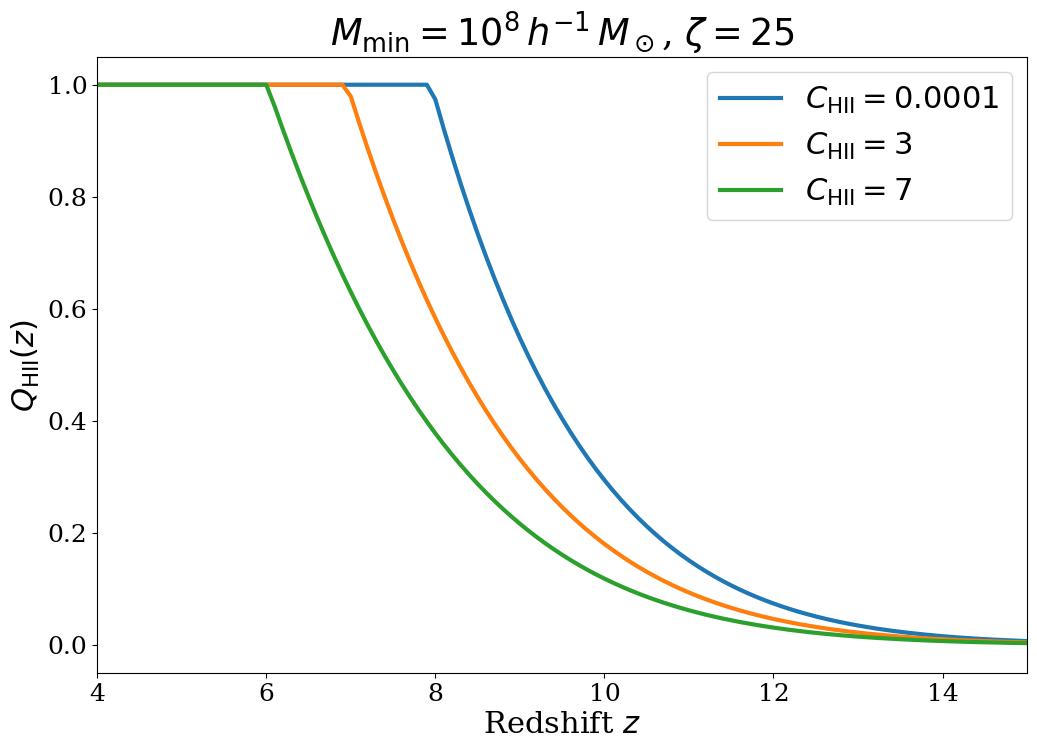

In [28]:
##################################################################
# Compare the reionization histories for different values of the
# clumping factor, keeping Mmin and zeta fixed
##################################################################

# List of clumping factors to be explored
CHII_list = [0.0001, 3, 7]

# Fixed reionization parameters
zeta = 25      # Ionizing efficiency parameter
Mmin = 1e8     # Minimum halo mass threshold (Msun/h)

# Compute and plot Q_HII(z) for each clumping factor
for C_HII in CHII_list:

    print(f"Computing Q_HII(z) for C_HII = {C_HII}...")

    # Solve the reionization equation
    z_arr, QHII_arr, z_end = get_QHII_arr(
        C_HII,
        zeta,
        Mmin
    )

    # Print the redshift at which reionization completes
    if z_end is not None:
        print(f"  Reionization completes at z = {z_end:.2f}")
    else:
        print("  Reionization is not completed within the redshift range considered.")

    # Plot the reionization history
    plt.plot(z_arr, QHII_arr, lw=3, label=rf'$C_{{\rm HII}}={C_HII}$')

    print("*"*10)

# Label the axes
plt.xlabel(r'Redshift $z$')
plt.ylabel(r'$Q_{\rm HII}(z)$')

# Display the fixed model parameters in the title
plt.title(
    rf'$M_{{\min}}=10^{{{int(np.log10(Mmin))}}}\,h^{{-1}}\,M_\odot$, '
    rf'$\zeta={zeta}$'
)

plt.xlim(4, 15)
plt.legend()
plt.savefig(f'figures/reion_hist_clumping_variations.png', dpi=300)
plt.show()

# Exercise 5: Effect of Ionizing Efficiency Parameter on Reionization History

#### a.  Making use of the `get_QHII_arr(C_HII, zeta, Mmin)` function developed in Exercise 2, plot $Q_{\rm HII}(z)$ for different zeta (say, $\zeta$ = [ 20, 25, 30]) assuming a fixed $M_{\rm min}$ (say,  $10^8 h^{-1} M_\odot$ ) and $C_{\rm HII}$ (say, 3) over the redshift range  $z=5$ to $z=15$

#### b.  Can you explain physically the dependence of $Q_{\rm HII} (z)$ on $\zeta$ ?

High zeta => same sources are ionizing more photons, so reionization starts earlier and ends earlier.

Computing Q_HII(z) for zeta = 20...
  Reionization completes at z = 6.40
**********
Computing Q_HII(z) for zeta = 25...
  Reionization completes at z = 6.90
**********
Computing Q_HII(z) for zeta = 30...
  Reionization completes at z = 7.30
**********


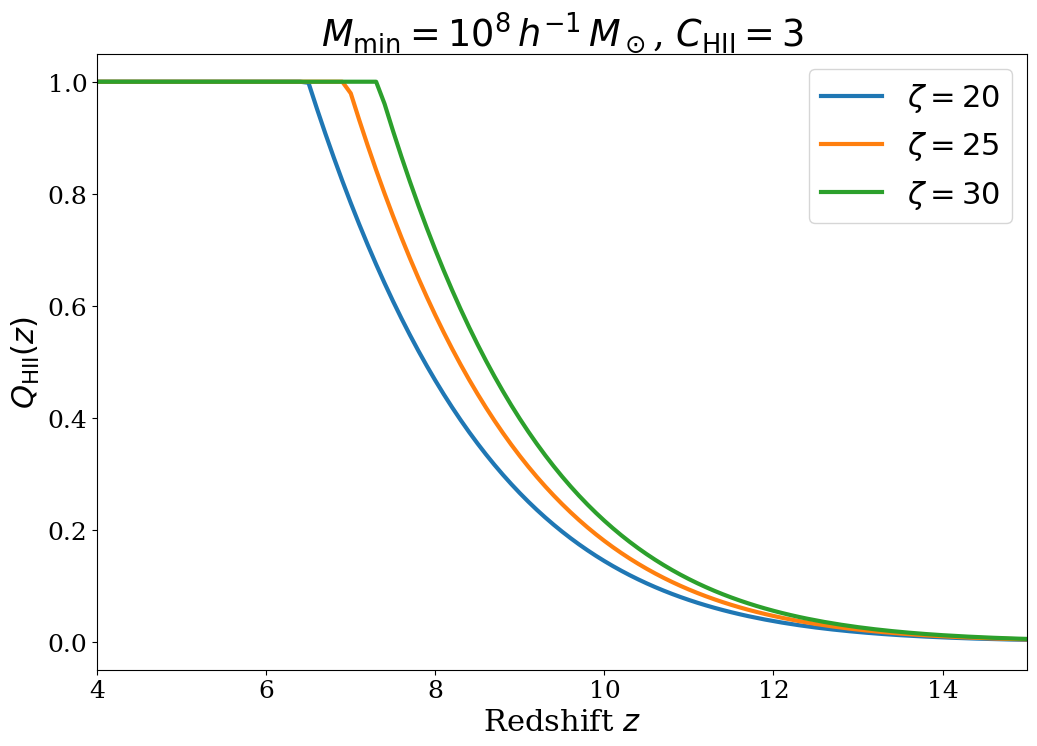

In [29]:
##################################################################
# Compare the reionization histories for different values of the
# ionizing efficiency parameter, keeping Mmin and CHII fixed
##################################################################

# List of ionizing efficiencies to be explored
zeta_list = [20, 25, 30]

# Fixed reionization parameters
C_HII = 3      # Clumping factor
Mmin = 1e8     # Minimum halo mass threshold (Msun/h)

# Compute and plot Q_HII(z) for each ionizing efficiency
for zeta in zeta_list:

    print(f"Computing Q_HII(z) for zeta = {zeta}...")

    # Solve the reionization equation
    z_arr, QHII_arr, z_end = get_QHII_arr(
        C_HII,
        zeta,
        Mmin
    )

    # Print the redshift at which reionization completes
    if z_end is not None:
        print(f"  Reionization completes at z = {z_end:.2f}")
    else:
        print("  Reionization is not completed within the redshift range considered.")

    # Plot the reionization history
    plt.plot(z_arr, QHII_arr, lw=3, label=rf'$\zeta={zeta}$')

    print("*" * 10)

# Label the axes
plt.xlabel(r'Redshift $z$')
plt.ylabel(r'$Q_{\rm HII}(z)$')

# Display the fixed model parameters in the title
plt.title(
    rf'$M_{{\min}}=10^{{{int(np.log10(Mmin))}}}\,h^{{-1}}\,M_\odot$, '
    rf'$C_{{\rm HII}}={C_HII}$'
)

plt.xlim(4, 15)
plt.legend()
plt.savefig('figures/reion_hist_zeta_variations.png', dpi=300)
plt.show()

# Exercise 6: Effect of $M_{\rm min}$ on Reionization History

#### a.  Making use of the `get_QHII_arr(C_HII, zeta, Mmin)` function developed in Exercise 2, plot $Q_{\rm HII}(z)$ for different values of $M_{\rm min}$ (say, $M_{\rm min}$ = [$10^{8}$, $10^{9}$, $10^{10}$] $h^{-1} M_\odot$)   assuming a fixed $\zeta$ (say,  $25$ ) and $C_{\rm HII}$ (say, 3) over the redshift range  $z=5$ to $z=15$

#### b.  Can you explain physically the dependence of $Q_{\rm HII} (z)$ on $M_{\rm min}$ ?

Computing Q_HII(z) for log10(Mmin) = 8...
  Reionization completes at z = 6.90
**********
Computing Q_HII(z) for log10(Mmin) = 9...
  Reionization completes at z = 5.70
**********
Computing Q_HII(z) for log10(Mmin) = 10...
  Reionization completes at z = 4.40
**********


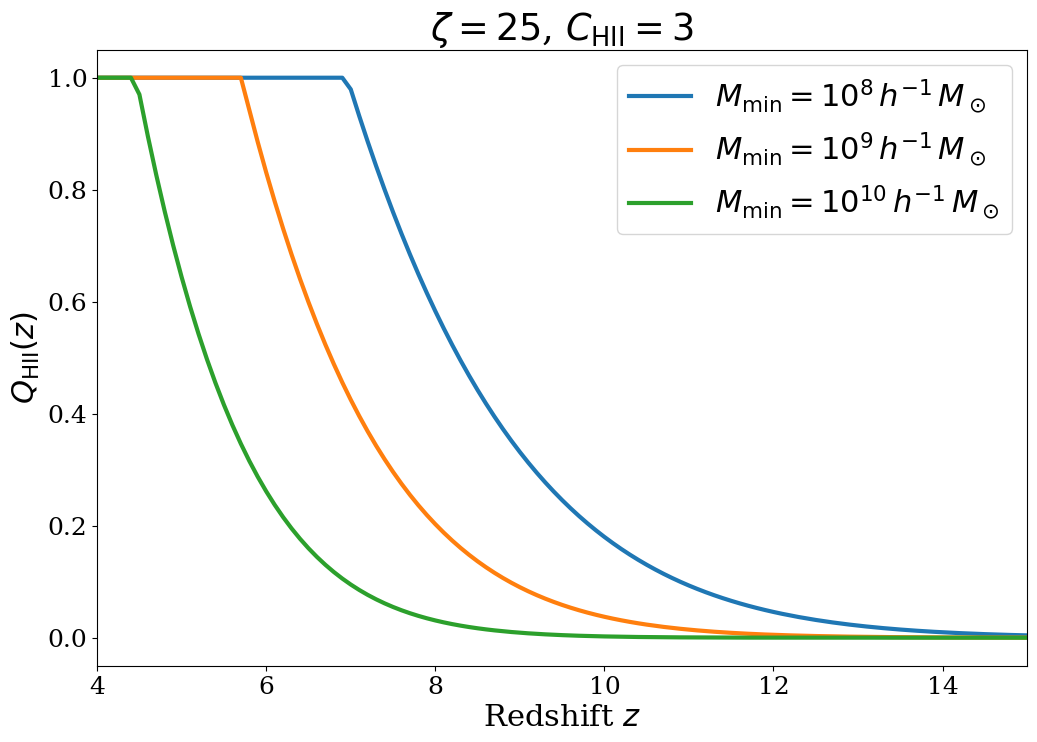

In [30]:
##################################################################
# Compare the reionization histories for different values of the
# minimum halo mass threshold, keeping zeta and CHII fixed
##################################################################

# List of minimum halo masses to be explored
log10Mmin_list = [8, 9, 10]   # log10(Mmin / (Msun/h))

# Fixed reionization parameters
C_HII = 3      # Clumping factor of ionized hydrogen
zeta = 25      # Ionizing efficiency parameter

# Compute and plot Q_HII(z) for each minimum halo mass
for log10Mmin in log10Mmin_list:

    Mmin = 10**log10Mmin

    print(f"Computing Q_HII(z) for log10(Mmin) = {log10Mmin}...")

    # Solve the reionization equation
    z_arr, QHII_arr, z_end = get_QHII_arr(
        C_HII,
        zeta,
        Mmin
    )

    # Print the redshift at which reionization completes
    if z_end is not None:
        print(f"  Reionization completes at z = {z_end:.2f}")
    else:
        print("  Reionization is not completed within the redshift range considered.")

    # Plot the reionization history
    plt.plot(z_arr, QHII_arr, lw=3,
        label=rf'$M_{{\min}}=10^{{{log10Mmin}}}\,h^{{-1}}\,M_\odot$'
    )

    print("*" * 10)

# Label the axes
plt.xlabel(r'Redshift $z$')
plt.ylabel(r'$Q_{\rm HII}(z)$')

# Display the fixed model parameters in the title
plt.title(
    rf'$\zeta={zeta}$, '
    rf'$C_{{\rm HII}}={C_HII}$'
)

plt.xlim(4, 15)
plt.legend()
plt.savefig('figures/reion_hist_Mmin_variations.png', dpi=300)
plt.show()

# Exercise 6: Comparing theoretical models with observational data

### Fix the clumping factor to $C_{\rm HII}=3$ and consider different combinations of the ionizing efficiency $\zeta$ and minimum halo mass $M_{\rm min}$.

### 1. For each $(\zeta, M_{\rm min})$ model, compute the neutral hydrogen fraction :  $Q_{\rm HI}(z) \equiv 1 - Q_{\rm HII}(z)$, the reionization optical depth : $\tau_{\rm e}(z)$, and the ionizing photon emissivity: $\dot{n}_{\rm ion}(z)$.

### 2. Plot the redshift evolution of these three quantities for all the chosen  $(\zeta, M_{\rm min})$ models.

### 3. Compare the model predictions with the provided observational constraints.

### 4. Identify the $(\zeta, M_{\rm min})$ combination(s) that best reproduce the observational datasets *simulateneously*.


In [33]:
##################################################################
# Store all observational data in a single structure
##################################################################

obs_data = {
    'QHI': [

        {
            'name': 'Davies+18',
            'z': np.array([7.09, 7.54]),
            'y': np.array([0.48, 0.60]),
            'yerr_plus': np.array([0.26, 0.20]),
            'yerr_minus': np.array([0.26, 0.23]),
            'fmt': 'X',
            'color': 'tab:brown'
        },

        {
            'name': 'Durovcikova+24',
            'z': np.array([6.10, 6.46, 6.87]),
            'y': np.array([0.21, 0.21, 0.37]),
            'yerr_plus': np.array([0.17, 0.33, 0.17]),
            'yerr_minus': np.array([0.07, 0.07, 0.17]),
            'fmt': 'd',
            'color': 'darkgoldenrod'
        },

        {
            'name': 'Greig+22',
            'z': np.array([7.29]),
            'y': np.array([0.49]),
            'yerr_plus': np.array([0.11]),
            'yerr_minus': np.array([0.11]),
            'fmt': '*',
            'color': 'crimson'
        },


        {
            'name': 'Gaikwad+23',
            'z': np.array([5.4, 5.5, 5.6, 5.7, 5.8, 5.9, 6.0]),
            'y': np.array([
                3.533e-03,
                7.246e-03,
                1.630e-02,
                5.596e-02,
                9.364e-02,
                1.282e-01,
                1.744e-01
            ]),
            'yerr_plus': np.array([
                15.084e-03,
                27.311e-03,
                2.544e-02,
                7.141e-02,
                6.182e-02,
                1.260e-01,
                0.925e-01
            ]),
            'yerr_minus': np.array([
                2.457e-03,
                3.506e-03,
                0.834e-02,
                3.362e-02,
                6.391e-02,
                0.736e-01,
                1.089e-01
            ]),
            'fmt': 'o',
            'color': 'black'
        },

        {
            'name': 'Umeda+24',
            'z': np.array([7.12, 7.44, 8.28, 9.91]),
            'y': np.array([0.53, 0.65, 0.91, 0.92]),
            'yerr_plus': np.array([0.18, 0.27, 0.09, 0.08]),
            'yerr_minus': np.array([0.47, 0.34, 0.22, 0.10]),
            'fmt': 'v',
            'color': 'rebeccapurple'
        }

    ],

    'tau': {
        'value': 0.056,
        'error': 0.007,
        'label': r'Planck Collab. (2018)',
        'color': 'gray'
    },

    'niondot': [

        {
            'name': 'Gaikwad+23',
            'z': np.array([
                4.9, 5.0, 5.1, 5.2, 5.3, 5.4,
                5.5, 5.6, 5.7, 5.8, 5.9, 6.0
            ]),
            'y': np.array([
                6.00e50, 5.63e50, 6.14e50, 6.68e50,
                6.24e50, 6.48e50, 5.87e50, 6.66e50,
                6.27e50, 6.09e50, 6.34e50, 7.01e50
            ]),
            'yerr_plus': np.array([
                3.04e50, 3.52e50, 4.75e50, 4.61e50,
                4.21e50, 4.62e50, 4.17e50, 4.02e50,
                3.40e50, 4.20e50, 3.43e50, 3.57e50
            ]),
            'yerr_minus': np.array([
                2.48e50, 2.07e50, 2.36e50, 2.38e50,
                1.98e50, 2.25e50, 1.49e50, 2.21e50,
                1.45e50, 1.41e50, 2.07e50, 1.91e50
            ]),
            'fmt': 'o',
            'color': 'k'
        },

    ]
}

zeta = 25, log10(Mmin / [Msun/h]) = 8, z_end = 6.90
[get_reion_tau] Reversing inputs so that z is in increasing order
******************************
zeta = 13.3, log10(Mmin / [Msun/h]) = 8, z_end = 5.50
[get_reion_tau] Reversing inputs so that z is in increasing order
******************************


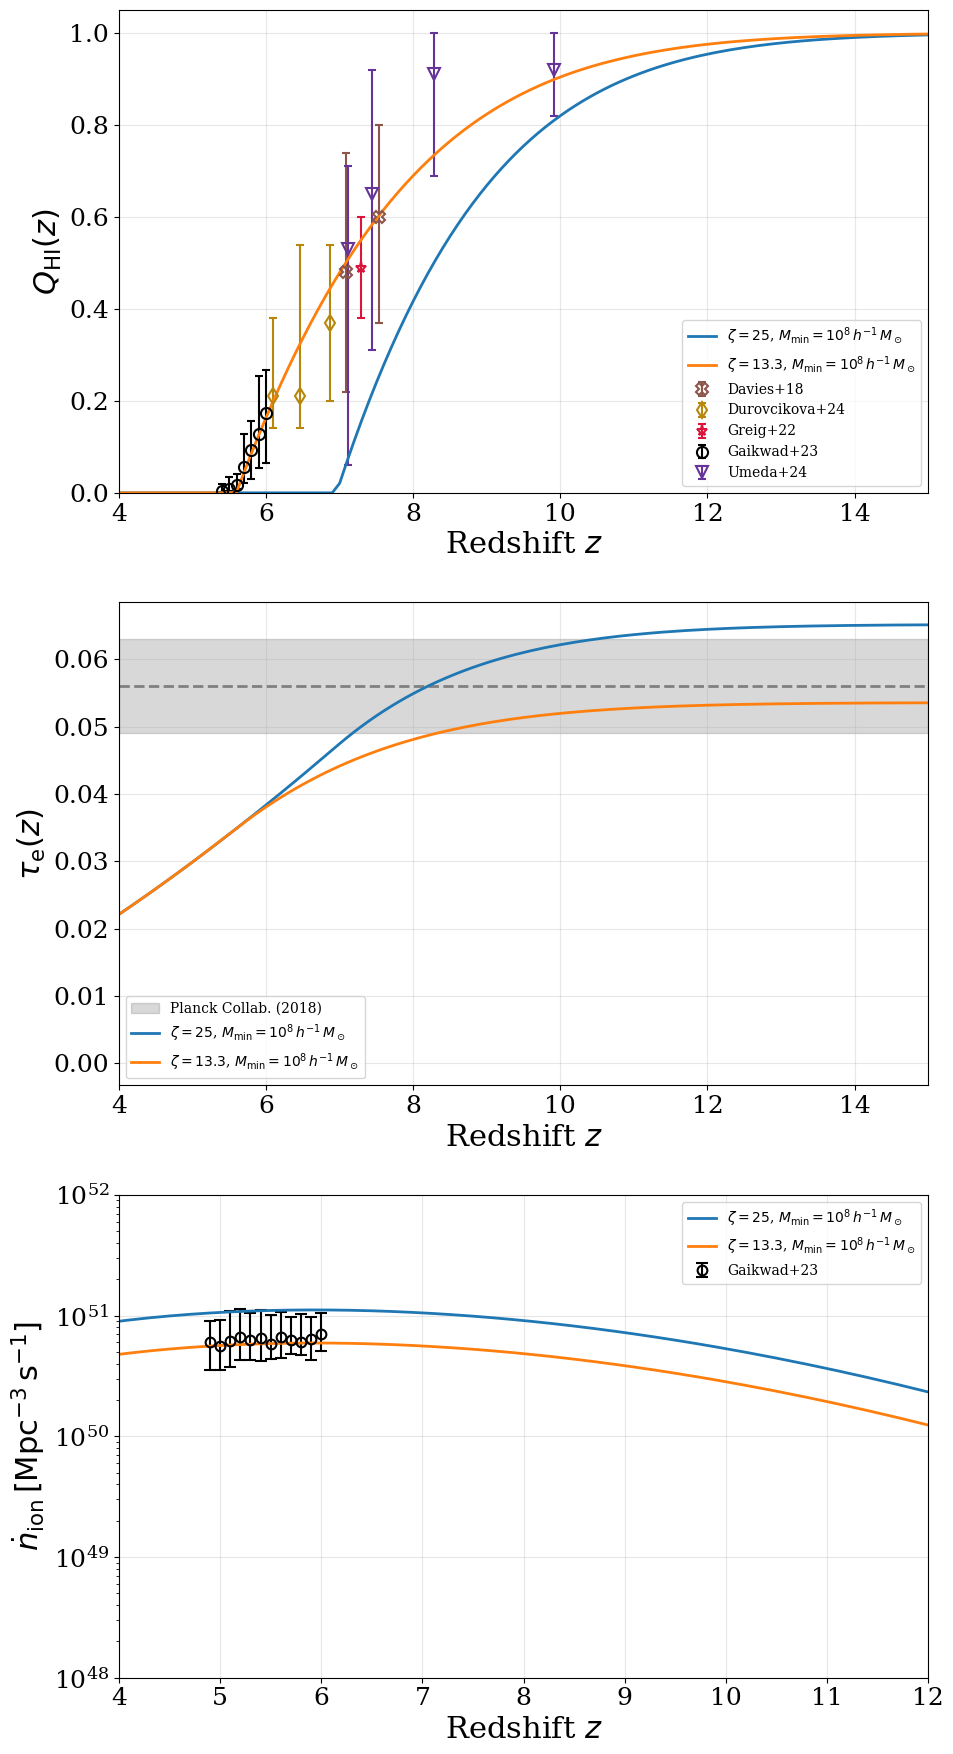

In [48]:
##################################################################
# Compare theoretical models with observational constraints
##################################################################

fig, (ax1, ax2, ax3) = plt.subplots(
    3, 1,
    figsize=(10, 3*6),
)

# Fixed reionization parameter
C_HII = 3

# (zeta, Mmin) models to be compared

models = [
    (25, 1e8),
    (13.3, 1e8)
]


# ------------------------------------------------------------
# Plot observational constraints: QHI
# ------------------------------------------------------------

for dataset in obs_data['QHI']:

    ax1.errorbar(
        dataset['z'],
        dataset['y'],
        yerr=[
            dataset['yerr_minus'],
            dataset['yerr_plus']
        ],
        fmt=dataset['fmt'],
        ms=8,
        capsize=3,
        color=dataset['color'],
        markerfacecolor='none',
        markeredgecolor=dataset['color'],
        markeredgewidth=1.5,
        label=dataset['name']
    )


# ------------------------------------------------------------
# Plot observational constraints: tau_reion
# ------------------------------------------------------------

tau_obs = obs_data['tau']

ax2.axhspan(
    tau_obs['value'] - tau_obs['error'],
    tau_obs['value'] + tau_obs['error'],
    alpha=0.3,
    color=tau_obs['color'],
    label=tau_obs['label']
)

ax2.axhline(
    tau_obs['value'],
    color=tau_obs['color'],
    lw=2,
    ls='--'
)
# ------------------------------------------------------------
# Plot observational constraints: niondot
# ------------------------------------------------------------

for dataset in obs_data['niondot']:

    ax3.errorbar(
        dataset['z'],
        dataset['y'],
        yerr=[
            dataset['yerr_minus'],
            dataset['yerr_plus']
        ],
        fmt=dataset['fmt'],
        ms=7,
        capsize=4,
        color=dataset['color'],
        markerfacecolor='none',
        markeredgecolor=dataset['color'],
        markeredgewidth=1.5,
        label=dataset['name']
    )



# ------------------------------------------------------------
# Compute and plot the theoretical models
# ------------------------------------------------------------

for zeta, Mmin in models:

    # Solve the reionization equation
    z_arr, QHII_arr, z_end = get_QHII_arr(
        C_HII=C_HII,
        zeta=zeta,
        Mmin=Mmin
    )

    print(
        f"zeta = {zeta}, "
        f"log10(Mmin / [Msun/h]) = {np.log10(Mmin):.0f}, "
        f"z_end = {z_end:.2f}"
    )

    # Compute the Thomson optical depth
    tau_arr, tau_reion = get_reion_tau(
        z_arr,
        QHII_arr
    )

    # Compute the ionizing photon emissivity
    niondot_arr = np.array([
        niondot(z, zeta, Mmin)
        for z in z_arr
    ])

    label = (
        rf'$\zeta={zeta}$, '
        rf'$M_{{\rm min}}=10^{{{np.log10(Mmin):.0f}}}\,h^{{-1}}\,M_\odot$'
    )

    # Neutral fraction evolution
    ax1.plot(
        z_arr,
        1.0 - QHII_arr,
        lw=2,
        label=label
    )

    # Thomson optical depth evolution
    ax2.plot(
        z_arr,
        tau_arr,
        lw=2,
        label=label
    )

    # Ionizing emissivity evolution
    ax3.plot(
        z_arr,
        niondot_arr,
        lw=2,
        label=label
    )
    print("**"*15)


# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------

ax1.set_xlabel(r'Redshift $z$')
ax1.set_ylabel(r'$Q_{\rm HI}(z)$')
ax1.set_xlim(4, 15)
ax1.set_ylim(0, 1.05)
ax1.grid(alpha=0.3)
ax1.legend(fontsize=10)

ax2.set_xlabel(r'Redshift $z$')
ax2.set_ylabel(r'$\tau_{\rm e}(z)$')
ax2.set_xlim(4, 15)
ax2.grid(alpha=0.3)
ax2.legend(fontsize=10)

ax3.set_xlabel(r'Redshift $z$')
ax3.set_ylabel(
    r'$\dot{n}_{\rm ion}\,$'
    r'$[\mathrm{Mpc^{-3}\,s^{-1}}]$'
)
ax3.set_xlim(4, 12)
ax3.set_ylim(1e48, 1e52)
ax3.set_yscale('log')
ax3.grid(alpha=0.3)
ax3.legend(fontsize=10)

plt.tight_layout()

plt.show()

$C_\mathrm{HII}$ fixed, constrain $M_{min}$ and $\zeta$.

# **Homework** :

## **An Empirical Model of the Ionizing Photon Emissivity**

In this exercise, we will construct a physically motivated model for the comoving ionizing photon emissivity,

The comoving ionizing photon emissivity, i.e. the number of hydrogen-ionizing photons emitted per unit time per unit comoving volume, can be written as

$$
\dot{n}_{\rm ion}(z)
=
\int_{-\infty}^{M_{\rm UV,min}}
f_{\rm esc}(M_{\rm UV},z)\,
\xi_{\rm ion}(M_{\rm UV},z)\,
L_{\rm UV}(M_{\rm UV})\,
\phi(M_{\rm UV},z)\,
dM_{\rm UV},
$$

where

- $\phi(M_{\rm UV},z)$ is the UV luminosity function,
- $L_{\rm UV}(M_{\rm UV})$ is the rest-frame UV luminosity at $1500\,\AA$  corresponding to the absolute magnitude $M_{\rm UV}$,
- $f_{\rm esc}(M_{\rm UV},z)$ is the escape fraction of ionizing photons, and
- $\xi_{\rm ion}(M_{\rm UV},z)$ is the ionizing photon production efficiency.

The limit, $M_{\rm UV,min}$, specifies the faintest galaxies assumed to contribute to reionization.

If both $f_{\rm esc}$ and $\xi_{\rm ion}$ are assumed to be independent of galaxy luminosity, then the emissivity can be rewritten as


$$
\dot{n}_{\rm ion}(z)
=
f_{\rm esc}(z)\,
\xi_{\rm ion}(z)\,
\rho_{\rm UV}(z),
$$

where

$$
\rho_{\rm UV}(z)
=
\int_{-\infty}^{M_{\rm UV,min}}
L_{\rm UV}(M_{\rm UV})\,
\phi(M_{\rm UV},z)\,
dM_{\rm UV}.
$$

Observational studies often provide empirical parameterisations for $\rho_{\rm UV}(z)$.

For example, by integrating the observed rest-frame UV luminosity function down to $M_{\rm UV}=-17$, [Donnan et al. (2024)](https://arxiv.org/abs/2403.03171) provided the following best-fit relation

$$
\log_{10}\rho_{\rm UV}(z)
=
-0.140\,z
+ 26.5,
$$

where $\rho_{\rm UV}$ is measured in units of ${\rm erg\,s^{-1}\,Hz^{-1}\,Mpc^{-3}}$.

## **Your Task**

1. Implement the following empirical model of ionizing emissivity --

   $$
   \dot{n}_{\rm ion}(z)
   =
   f_{\rm esc}(z)\,
   \xi_{\rm ion}\,
   \rho_{\rm UV}(z),
   $$

   We will treat $f_{\rm esc}(z)$ as a free parameter or free function.

2. Use this model of $\dot{n}_{\rm ion}(z)$ to compute the reionization history, $Q_{\rm HII}(z)$, and the electron scattering optical depth, $\tau_{\rm reion}$. Explore different parameterisations of $f_{\rm esc}(z)$ and identify a model that simultaneously reproduce the observed constraints on $\dot{n}_{\rm ion}(z)$, $Q_{\rm HII}(z)$, and $\tau_{\rm reion}$. You may fix $C_{\rm HII}=3$ for this exercise, if you wish